# Tutorial 7: Survey geometries

Comparing a galaxy formation model against survey data means knowing
exactly *where* the survey looked: its angular mask on the sky, and how
far away a galaxy of given luminosity or mass remains detectable. In
Galacticus this is the `surveyGeometry` class, used to compute
$V_\mathrm{max}$ weights for luminosity/mass functions and window
functions for power-spectrum comparisons.

Highlights of this tutorial:

* the SDSS angular mask of Bernardi et al. (2013), driven through its
  [mangle](https://zenodo.org/records/10998446) polygon representation —
  including reconstructing the survey footprint point by point;
* $V_\mathrm{max}(M)$, the workhorse of mass-function estimation;
* Fourier-space **window functions** on a 3D grid (computed by FFTW inside
  Galacticus, returned to Python as complex arrays), cross-validated
  against numpy's FFT and the analytic expectation — for the full sky
  *and* for the real SDSS mask, Monte-Carlo sampled from its polygons;
* the payoff: **convolving a theory power spectrum with a survey
  window**, the operation at the heart of every P(k) comparison.

In [1]:
import os, sys

# Locate the Galacticus library interface (see Tutorial 1 for details).
root = os.environ.get('GALACTICUS_LIBRARY_PATH',
                      os.path.abspath(os.path.join(os.getcwd(), os.pardir)))
os.chdir(root)   # galacticus.py loads galacticus/lib/libgalacticus.so relative to here
for candidate in (root, os.path.join(root, 'galacticus', 'python')):
    if os.path.exists(os.path.join(candidate, 'galacticus.py')):
        sys.path.insert(0, candidate)
        break
else:
    raise RuntimeError(f"galacticus.py not found under {root} - build the library "
                       "(make GALACTICUS_BUILD_OPTION=lib libgalacticus.so) or set "
                       "GALACTICUS_LIBRARY_PATH")

# This tutorial reads survey mask data (mangle polygons) through
# GALACTICUS_DATA_PATH: clone https://github.com/galacticusorg/datasets and
# point GALACTICUS_DATA_PATH at it. (The SDSS mask is fetched into
# datasets/dynamic/ on first use.)
if 'GALACTICUS_DATA_PATH' not in os.environ:
    raise RuntimeError("set GALACTICUS_DATA_PATH to a clone of "
                       "https://github.com/galacticusorg/datasets")

import numpy as np
import matplotlib.pyplot as plt
import galacticus
print("Galacticus library interface loaded.")

Galacticus library interface loaded.


In [2]:
plt.rcParams.update({'figure.figsize': (7.0, 4.5), 'font.size': 11,
                     'axes.grid': True, 'grid.alpha': 0.3})

## The SDSS mask of Bernardi et al. (2013)

The constructor takes no arguments; the survey's mangle polygon file is
fetched into the dynamic datasets on first use, and derived quantities
(like solid angles) are cached alongside it. The mangle project quotes a
solid angle of $2.232262776405\,\mathrm{sr}$ for this mask, computed with
its `harmonize` utility — Galacticus reproduces it from the polygons.

In [3]:
sdss = galacticus.surveyGeometryBernardi2013SDSS()
solidAngle = sdss.solidAngle()
print(f"fields                : {sdss.fieldCount()}")
print(f"solid angle           : {solidAngle:.12f} sr")
print(f"mangle harmonize value: 2.232262776405 sr")
print(f"sky fraction          : {solidAngle/4.0/np.pi:.4f}")
assert np.isclose(solidAngle, 2.232262776405, rtol=1.0e-9)

fields                : 1
solid angle           : 2.232262776405 sr
mangle harmonize value: 2.232262776405 sr
sky fraction          : 0.1776


### The survey footprint, from `pointIncluded`

`pointIncluded(position, mass)` answers the fundamental membership
question: would a galaxy of this mass, at this comoving position, appear
in the survey? Sampling directions on the sky at a fixed (small) distance
reconstructs the angular mask — the familiar SDSS contiguous northern
footprint emerges from pure polygon tests.

The first mask query parses the full 200,000-polygon file (about a
minute, with a progress bar written straight to the process's stdout);
`galacticus.verbositySet('silent')` quiets that output.

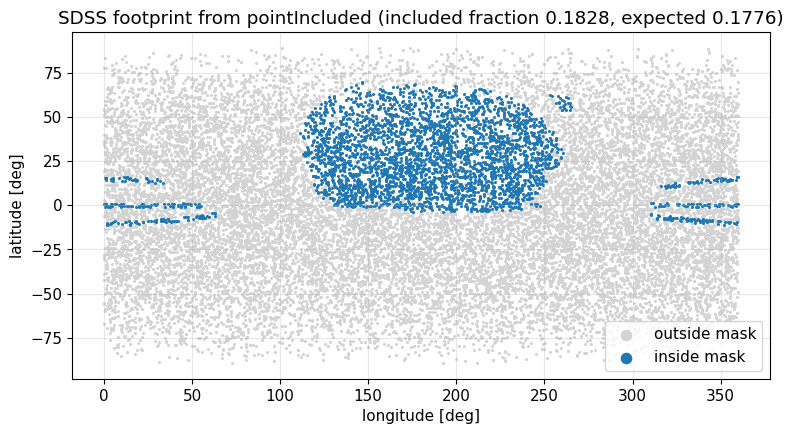

In [4]:
galacticus.verbositySet('silent')   # quiet the polygon-reading progress bar
rng = np.random.default_rng(20260705)
nPoints  = 20000
distance = 50.0                                       # Mpc — well inside the survey
# Uniform points on the sphere.
u, v = rng.random(nPoints), rng.random(nPoints)
phi      = 2.0*np.pi*u                                # RA-like angle
cosTheta = 2.0*v-1.0
sinTheta = np.sqrt(1.0-cosTheta**2)
points   = distance*np.column_stack([sinTheta*np.cos(phi),
                                     sinTheta*np.sin(phi),
                                     cosTheta])
included = np.array([sdss.pointIncluded(p, 1.0e11) for p in points])

ra  = np.degrees(phi)
dec = np.degrees(np.arcsin(cosTheta))
plt.figure(figsize=(9, 4.5))
plt.scatter(ra[~included], dec[~included], s=1.5, color='lightgray', label='outside mask')
plt.scatter(ra[ included], dec[ included], s=1.5, color='C0'       , label='inside mask')
plt.xlabel('longitude [deg]'); plt.ylabel('latitude [deg]')
plt.legend(loc='lower right', markerscale=6)
plt.title(f'SDSS footprint from pointIncluded '
          f'(included fraction {included.mean():.4f}, '
          f'expected {solidAngle/4.0/np.pi:.4f})')
plt.show()
# The Monte-Carlo included fraction must reproduce the mask's solid angle.
assert abs(included.mean()-solidAngle/4.0/np.pi) < 5.0/np.sqrt(nPoints)

## $V_\mathrm{max}$: how far can you see a galaxy of mass $M$?

For a flux-limited survey, more massive (more luminous) galaxies are
visible to larger distances. `distanceMaximum(mass)` encodes the survey's
selection, and `volumeMaximum` is the comoving volume within which each
galaxy could have been detected — the denominator of the classic
$1/V_\mathrm{max}$ estimator for mass functions.

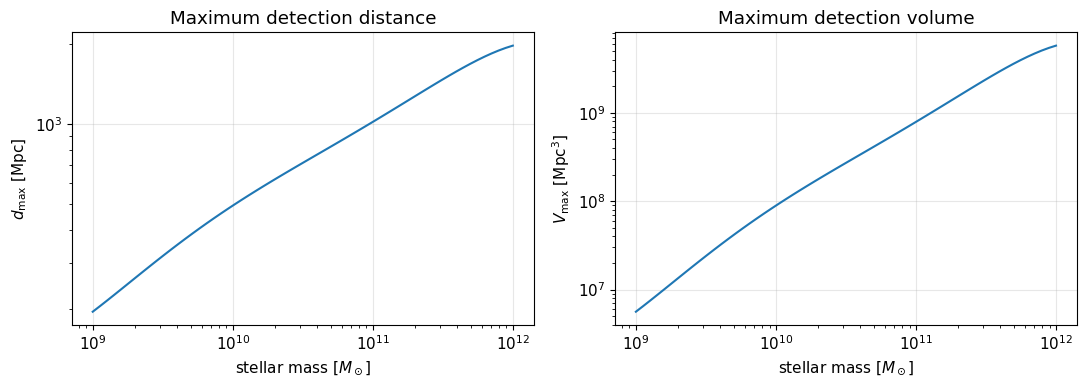

In [5]:
masses = np.logspace(9.0, 12.0, 60)
dMax = np.array([sdss.distanceMaximum(mass=M) for M in masses])
vMax = np.array([sdss.volumeMaximum(M)        for M in masses])
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].loglog(masses, dMax)
axes[0].set_xlabel('stellar mass [$M_\\odot$]'); axes[0].set_ylabel('$d_\\mathrm{max}$ [Mpc]')
axes[0].set_title('Maximum detection distance')
axes[1].loglog(masses, vMax)
axes[1].set_xlabel('stellar mass [$M_\\odot$]'); axes[1].set_ylabel('$V_\\mathrm{max}$ [Mpc$^3$]')
axes[1].set_title('Maximum detection volume')
fig.tight_layout(); plt.show()

Multi-field surveys expose per-field geometry — e.g. the three equatorial
regions of GAMA (Baldry et al. 2012):

In [6]:
cosmologyParameters = galacticus.cosmologyParametersSimple(0.3, 0.045, 0.7, 2.78, 70.0)
cosmologyFunctions  = galacticus.cosmologyFunctionsMatterLambda(cosmologyParameters)
gama = galacticus.surveyGeometryBaldry2012GAMA(cosmologyFunctions)
for field in range(1, gama.fieldCount()+1):
    print(f"GAMA field {field}: solid angle = {gama.solidAngle(field):.6f} sr")

GAMA field 1: solid angle = 0.014616 sr
GAMA field 2: solid angle = 0.014619 sr
GAMA field 3: solid angle = 0.014619 sr


## Window functions in Fourier space

Comparing measured power spectra with theory requires convolving $P(k)$
with the survey's *window function* — the Fourier transform of its
selection volume. `windowFunctions(mass1, mass2, gridCount)` builds the
selection function on a 3D grid, FFTs it with FFTW inside Galacticus, and
returns the two complex window grids to Python (normalized to
$W(\mathbf{k}=0)=1$).

Here we use the all-sky geometry, whose selection volume for $z \le 0.1$
is a solid sphere — so the exact answer is the classic spherical top-hat,
$W(k) = 3\,j_1(kR)/(kR)$, and we can validate the machinery three
independent ways.

In [7]:
fullSky = galacticus.surveyGeometryFullSky(redshiftMinimum=0.0, redshiftMaximum=0.1,
                                           cosmologyFunctions_=cosmologyFunctions)
gridCount = 64
boxLength, window1, window2 = fullSky.windowFunctions(1.0e10, 1.0e10, gridCount)
radiusSurvey = fullSky.distanceMaximum(1.0e10)
print(f"box length      : {boxLength:8.2f} Mpc")
print(f"survey radius   : {radiusSurvey:8.2f} Mpc  (z=0.1)")
print(f"window grid     : {window1.shape}, dtype {window1.dtype}")
print(f"W(k=0)          : {window1[0,0,0]}")

# Validation 1: Galacticus's FFTW result vs numpy's FFT of the identically
# discretized selection function — must agree to machine precision.
x = (np.arange(1, gridCount+1)-0.5)*boxLength/gridCount - boxLength/2.0
X, Y, Z = np.meshgrid(x, x, x, indexing='ij')
selection = (np.sqrt(X**2+Y**2+Z**2) < radiusSurvey).astype(complex)
windowNumpy = np.fft.fftn(selection); windowNumpy /= windowNumpy[0,0,0]
error = np.max(np.abs(window1-windowNumpy))
print(f"max |W_Galacticus - W_numpy| = {error:.3e}")
assert error < 1.0e-10

box length      :  1255.99 Mpc
survey radius   :   418.66 Mpc  (z=0.1)
window grid     : (64, 64, 64), dtype complex128
W(k=0)          : (1+0j)
max |W_Galacticus - W_numpy| = 2.222e-16


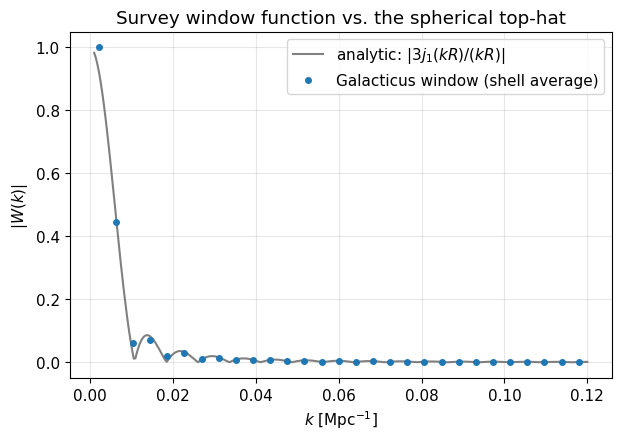

In [8]:
# Validation 2: the radial profile of |W(k)| against the analytic
# spherical top-hat 3 j1(kR)/(kR).
kGrid = 2.0*np.pi*np.fft.fftfreq(gridCount, d=boxLength/gridCount)
KX, KY, KZ = np.meshgrid(kGrid, kGrid, kGrid, indexing='ij')
kMagnitude = np.sqrt(KX**2+KY**2+KZ**2)

def windowTopHat(k, R):
    x = np.maximum(k*R, 1.0e-10)
    return 3.0*(np.sin(x)-x*np.cos(x))/x**3

kBins  = np.linspace(0.0, 0.12, 30)
kMid   = 0.5*(kBins[1:]+kBins[:-1])
profile = np.array([np.mean(np.abs(window1)[(kMagnitude >= lo) & (kMagnitude < hi)])
                    for lo, hi in zip(kBins[:-1], kBins[1:])])
kSmooth = np.linspace(1.0e-3, 0.12, 300)
plt.plot(kSmooth, np.abs(windowTopHat(kSmooth, radiusSurvey)), color='gray',
         label='analytic: $|3 j_1(kR)/(kR)|$')
plt.plot(kMid, profile, 'o', ms=4, color='C0', label='Galacticus window (shell average)')
plt.xlabel('$k$ [Mpc$^{-1}$]'); plt.ylabel('$|W(k)|$')
plt.legend(); plt.title('Survey window function vs. the spherical top-hat')
plt.show()

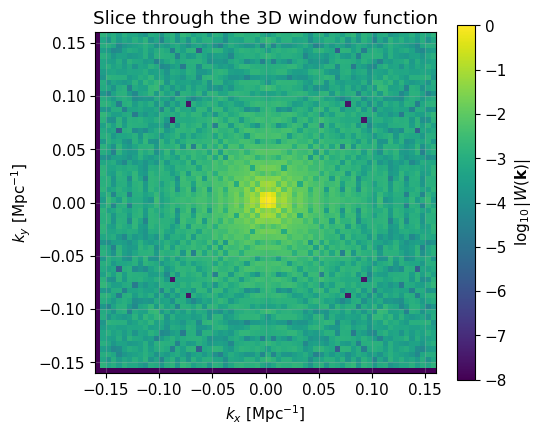

In [9]:
# Validation 3 (by eye): a slice through the 3D window — the ringing
# pattern of the top-hat transform.
plt.figure(figsize=(5.5, 4.6))
slicePlane = np.abs(np.fft.fftshift(window1)[:, :, gridCount//2])
kMax = np.abs(kGrid).max()
plt.imshow(np.log10(np.maximum(slicePlane, 1.0e-8)),
           extent=[-kMax, kMax, -kMax, kMax], origin='lower', cmap='viridis')
plt.colorbar(label='$\\log_{10} |W(\\mathbf{k})|$')
plt.xlabel('$k_x$ [Mpc$^{-1}$]'); plt.ylabel('$k_y$ [Mpc$^{-1}$]')
plt.title('Slice through the 3D window function')
plt.show()

## A real survey's window function

Mangle-based geometries build their window functions by Monte-Carlo
sampling the polygon mask (polygons drawn in proportion to their solid
angles, depths uniform in volume within the survey's limits). This needs a
random number generator — pass one to the survey's constructor. The
sampling takes a minute or so for the 200,000-polygon SDSS mask.

window functions available without RNG: False
window functions available with    RNG: True


<>:22: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:22: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/tmp/ipykernel_4017964/281119426.py:22: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  fig.colorbar(im, ax=ax, label='$\log_{10}|W|$')


box length: 3060.8 Mpc,  W(0) = (1+0j)


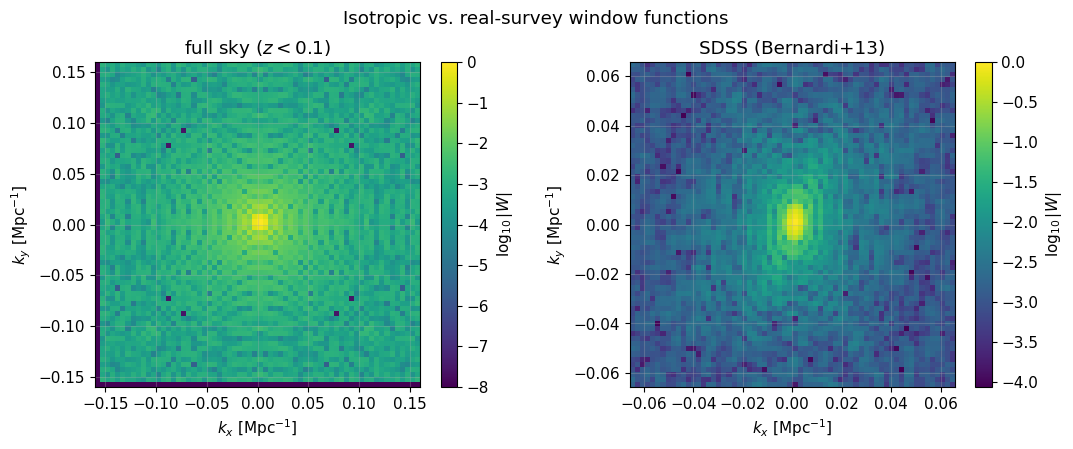

In [10]:
randomNumberGenerator = galacticus.randomNumberGeneratorGSL(
    seed_=8675309, ompThreadOffset=False, mpiRankOffset=False)
sdssSampled = galacticus.surveyGeometryBernardi2013SDSS(
    randomNumberGenerator_=randomNumberGenerator)
print(f"window functions available without RNG: {sdss.windowFunctionAvailable()}")
print(f"window functions available with    RNG: {sdssSampled.windowFunctionAvailable()}")

boxLengthSDSS, windowSDSS, _ = sdssSampled.windowFunctions(1.0e11, 1.0e11, gridCount)
print(f"box length: {boxLengthSDSS:.1f} Mpc,  W(0) = {windowSDSS[0,0,0]}")
assert windowSDSS[0,0,0] == 1.0+0j

kGridSDSS = 2.0*np.pi*np.fft.fftfreq(gridCount, d=boxLengthSDSS/gridCount)
kMaxSDSS  = np.abs(kGridSDSS).max()
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, W, kM, label in ((axes[0], window1, np.abs(kGrid).max(), 'full sky ($z<0.1$)'),
                         (axes[1], windowSDSS, kMaxSDSS, 'SDSS (Bernardi+13)')):
    sliceW = np.abs(np.fft.fftshift(W)[:, :, W.shape[2]//2])
    im = ax.imshow(np.log10(np.maximum(sliceW, 1.0e-8)),
                   extent=[-kM, kM, -kM, kM], origin='lower', cmap='viridis')
    ax.set_xlabel('$k_x$ [Mpc$^{-1}$]'); ax.set_ylabel('$k_y$ [Mpc$^{-1}$]')
    ax.set_title(label)
    fig.colorbar(im, ax=ax, label='$\log_{10}|W|$')
fig.suptitle('Isotropic vs. real-survey window functions')
fig.tight_layout(); plt.show()

The full-sky window rings symmetrically; the SDSS window is visibly
anisotropic — the imprint of the survey's footprint on Fourier space.

## Finale: convolving $P(k)$ with the survey window

What a survey measures is not $P(k)$ but its convolution with
$|W(\mathbf{k})|^2$:
$$P_\mathrm{obs}(\mathbf{k}) \;=\; \frac{\sum_{\mathbf{k}'} P(k')\,|W(\mathbf{k}-\mathbf{k}')|^2}{\sum_{\mathbf{k}'} |W(\mathbf{k}')|^2}.$$
We assemble the linear power spectrum from Tutorial 2, evaluate it on the
full-sky window's Fourier grid, and perform the convolution with FFTs.
The window kernel $|W|^2$ has width $\Delta k \sim 2\pi/R$ where $R$ is
the survey extent — here a *compact* kernel, so the redistribution of
power is at the few-per-cent level and largest where $P(k)$ changes
fastest (near the largest scales and the spectrum's turnover). Shallower
or narrower surveys have broader kernels and correspondingly stronger
distortions — the machinery below applies unchanged.

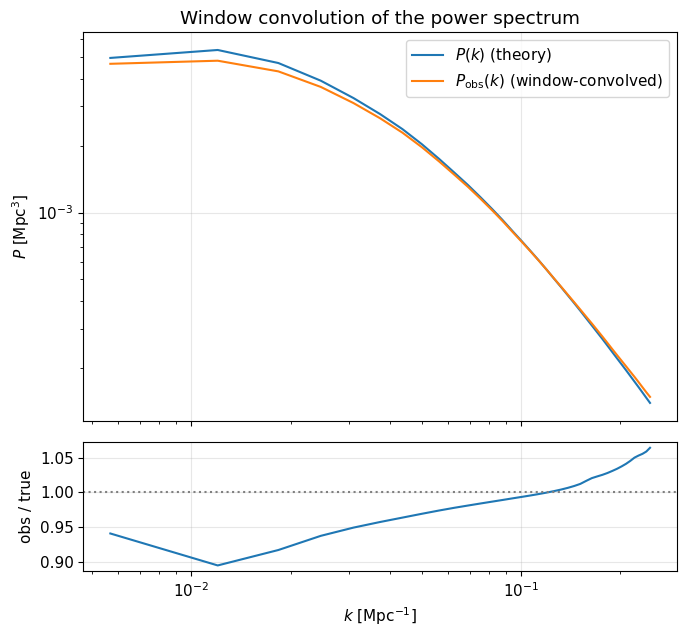

obs/true at k=0.0057: 0.941
obs/true at k=0.247: 1.064


In [11]:
# The linear power spectrum (Tutorial 2's object graph, condensed).
darkMatterParticle      = galacticus.darkMatterParticleCDM()
transferFunction        = galacticus.transferFunctionEisensteinHu1999(
    3.046, 0.0, darkMatterParticle, cosmologyParameters, cosmologyFunctions)
linearGrowth            = galacticus.linearGrowthCollisionlessMatter(cosmologyParameters, cosmologyFunctions)
powerSpectrumPrimordial = galacticus.powerSpectrumPrimordialPowerLaw(0.965, 0.0, 0.0, 1.0, False)
powerSpectrum           = galacticus.powerSpectrumPrimordialTransferredSimple(
    powerSpectrumPrimordial, transferFunction, linearGrowth)
ageToday = cosmologyFunctions.cosmicTime(1.0)

# Evaluate P(|k|) on the window's Fourier grid (binned by |k| for speed).
kFlat   = kMagnitude.ravel()
order   = np.argsort(kFlat)
pFlat   = np.zeros_like(kFlat)
kUnique, inverse = np.unique(np.round(kFlat, 12), return_inverse=True)
pUnique = np.array([powerSpectrum.power(k, ageToday) if k > 0.0 else 0.0
                    for k in kUnique])
pGrid   = pUnique[inverse].reshape(kMagnitude.shape)

# Circular convolution via the convolution theorem, normalized so that a
# constant spectrum is preserved.
windowSquared = np.abs(window1)**2
pConvolved = np.real(np.fft.ifftn(np.fft.fftn(pGrid)*np.fft.fftn(windowSquared)))
pConvolved /= np.sum(windowSquared)

# Shell-average both and compare.
kBins = np.linspace(kGrid[1]*0.5, 0.25, 40)
kMid  = 0.5*(kBins[1:]+kBins[:-1])
def shellAverage(field):
    return np.array([np.mean(field[(kMagnitude >= lo) & (kMagnitude < hi)])
                     for lo, hi in zip(kBins[:-1], kBins[1:])])
pTrue, pObs = shellAverage(pGrid), shellAverage(pConvolved)

fig, (axP, axR) = plt.subplots(2, 1, figsize=(7, 6.5), sharex=True,
                               gridspec_kw={'height_ratios': (3, 1)})
axP.loglog(kMid, pTrue, label='$P(k)$ (theory)')
axP.loglog(kMid, pObs , label='$P_{\\rm obs}(k)$ (window-convolved)')
axP.set_ylabel('$P$ [Mpc$^3$]'); axP.legend()
axP.set_title('Window convolution of the power spectrum')
axR.semilogx(kMid, pObs/pTrue); axR.axhline(1.0, color='gray', ls=':')
axR.set_xlabel('$k$ [Mpc$^{-1}$]'); axR.set_ylabel('obs / true')
fig.tight_layout(); plt.show()

# Quantitative signatures for this compact window: percent-level
# redistribution everywhere, approaching unity in the well-sampled
# intermediate range.
print(f"obs/true at k={kMid[0]:.4f}: {pObs[0]/pTrue[0]:.3f}")
print(f"obs/true at k={kMid[-1]:.3f}: {pObs[-1]/pTrue[-1]:.3f}")
assert np.all(np.abs(pObs/pTrue-1.0) < 0.20)
assert abs(pObs[-1]/pTrue[-1]-1.0) < 0.10

## Where next

Every mask operation here (`pointIncluded` above all) is exactly what
Galacticus itself uses when constructing mock catalogues on lightcones,
and the window-convolution above is the forward model for comparing
Tutorial 2's spectra — CDM or WDM — with survey measurements. For
higher-fidelity survey windows, increase the grid size (and note that
`angularPower` computes the mask's spherical-harmonic decomposition from
the polygon file on first use — an expensive, cached operation).